# Compare results from Models A-D
- see if possible to develop bias auditing framework based on results

# libraries

In [32]:

from pathlib import Path
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import os

import folium
from sklearn.cluster import DBSCAN
from collections import Counter

# load + clean data

In [33]:
for f in Path("model_results").glob("*.csv"):
    globals()[f.stem] = pd.read_csv(f)


In [34]:
all_csv_files = (
    glob.glob("../1.Data_Collection_Prep/clean_final_datasets/*.csv"))

for file in all_csv_files:
    file_name = os.path.splitext(os.path.basename(file))[0]
    globals()[file_name] = pd.read_csv(file)

print(f"Loaded {len(all_csv_files)} CSV files")

Loaded 4 CSV files


In [35]:
player_personal_data = player_personal_data
college_performance = college_performance_history
player_master = player_master
nfl_performance = nfl_draft_stats

In [36]:
## filenames
Model_A_results = Model_A_results

Model_B_results  = Model_B_results

Model_C_results = Model_C_results

Model_D_results = Model_D_results

## filter all data for only tested athletes

In [38]:
nfl_performance['athlete_id'] = nfl_performance['espn_id'].astype(str)
player_personal_data['athlete_id'] = player_personal_data['athlete_id'].astype(str)
college_performance['athlete_id'] = college_performance['athlete_id'].astype(str)
player_master['athlete_id'] = player_master['athlete_id'].astype(str)
Model_A_results['athlete_id'] = Model_A_results['athlete_id'].astype(str)
Model_B_results['athlete_id'] = Model_B_results['athlete_id'].astype(str)
Model_C_results['athlete_id'] = Model_C_results['athlete_id'].astype(str)
Model_D_results['athlete_id'] = Model_D_results['athlete_id'].astype(str)

In [39]:
valid_ids = set(Model_A_results["athlete_id"])

player_personal_data = player_personal_data[player_personal_data["athlete_id"].isin(valid_ids)]
player_master = player_master[player_master["athlete_id"].isin(valid_ids)]
college_performance = college_performance[college_performance["athlete_id"].isin(valid_ids)]

## label model predictions in all datasets

In [42]:
def label_row(true_label, pred_label):
    if pred_label == 1 and true_label == 1:
        return "rec_draft"
    if pred_label == 0 and true_label == 1:
        return "rej_draft"
    if pred_label == 1 and true_label == 0:
        return "rec_nd"
    return "rej_nd"

def add_model_cols(df, results_df, prefix):
    tmp = results_df[["athlete_id", "true_label", "rf_pred", "xgb_pred"]]

    df = df.merge(tmp, on="athlete_id", how="left")

    df[f"{prefix}_rf"] = df.apply(
        lambda r: label_row(r["true_label"], r["rf_pred"]), axis=1
    )
    df[f"{prefix}_xgb"] = df.apply(
        lambda r: label_row(r["true_label"], r["xgb_pred"]), axis=1
    )

    return df.drop(columns=["true_label", "rf_pred", "xgb_pred"])


In [43]:
models = {
    "A": Model_A_results,
    "B": Model_B_results,
    "C": Model_C_results,
    "D": Model_D_results
}

datasets = [
    "player_personal_data",
    "player_master",
    "college_performance"
]

for name in datasets:
    for m, res in models.items():
        globals()[name] = add_model_cols(globals()[name], res, m)

# Compare NFL Outcomes vs Model Corectness - EDA

In [44]:
nfl_performance.columns

Index(['espn_id', 'display_name', 'position', 'draft_year', 'draft_round',
       'draft_pick', 'nfl_value', 'years_played', 'total_games',
       'total_pass_yards', 'total_pass_tds', 'total_rush_yards',
       'total_rush_tds', 'total_rec_yards', 'total_rec_tds',
       'total_receptions', 'total_tackles', 'total_sacks',
       'total_interceptions', 'athlete_id'],
      dtype='str')

## performance outcoems, general

In [ ]:
def analyze_model_performance_vs_nfl_outcomes():
    
    nfl_value_order = ['Long_Term_Success', 'Short_Term_Success', 'Made_Roster', 'Failed', 'Never_Played']
    
    model_cols = ['A_rf', 'A_xgb', 'B_rf', 'B_xgb', 'C_rf', 'C_xgb', 'D_rf', 'D_xgb']
    
    analysis_data = player_master.merge(
        nfl_performance[['athlete_id', 'nfl_value']], 
        on='athlete_id', 
        how='left'
    )
    
    drafted_players = analysis_data.dropna(subset=['nfl_value']).copy()
    
    print(f"Analyzing {len(drafted_players)} drafted players")
    
    model_performance = {}
    
    for model in model_cols:
        model_data = drafted_players[drafted_players[model].notna()].copy()
        
        performance_matrix = pd.crosstab(
            model_data[model], 
            model_data['nfl_value']
        )
        
        performance_matrix = performance_matrix.reindex(
            columns=[col for col in nfl_value_order if col in performance_matrix.columns]
        )
        
        model_performance[model] = {
            'matrix': performance_matrix,
            'total_players': len(model_data),
            'rec_draft_success': len(model_data[
                (model_data[model] == 'rec_draft') & 
                (model_data['nfl_value'].isin(['Long_Term_Success', 'Short_Term_Success']))
            ]),
            'rej_draft_missed_gems': len(model_data[
                (model_data[model] == 'rej_draft') & 
                (model_data['nfl_value'].isin(['Long_Term_Success', 'Short_Term_Success']))
            ])
        }
    
    return model_performance, drafted_players, nfl_value_order

model_performance, drafted_players, nfl_value_order = analyze_model_performance_vs_nfl_outcomes()


Analyzing 289 drafted players


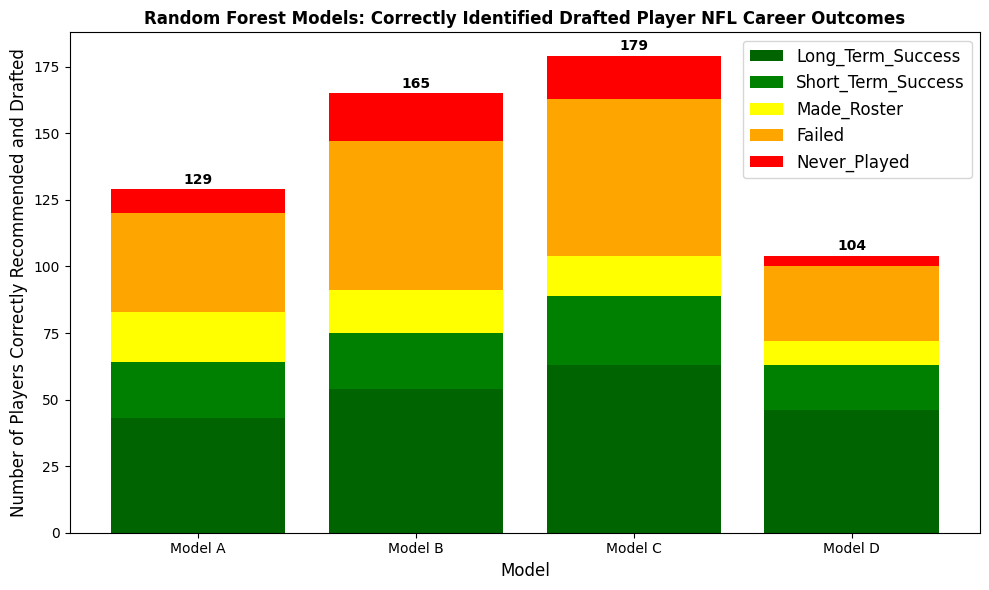

In [73]:
model_cols = ['A_rf', 'B_rf', 'C_rf', 'D_rf']
model_labels = ['Model A', 'Model B', 'Model C', 'Model D']

data_for_plot = {}
nfl_outcomes = ['Long_Term_Success', 'Short_Term_Success', 'Made_Roster', 'Failed', 'Never_Played']

for outcome in nfl_outcomes:
    data_for_plot[outcome] = []

for model in model_cols:
    if model in model_performance:
        perf_matrix = model_performance[model]['matrix']
        rec_draft_row = perf_matrix.loc['rec_draft']
        for outcome in nfl_outcomes:
            data_for_plot[outcome].append(rec_draft_row[outcome])
    else:
        for outcome in nfl_outcomes:
            data_for_plot[outcome].append(0)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bottom = [0] * len(model_labels)
colors = ['darkgreen', 'green', 'yellow', 'orange', 'red']

for i, outcome in enumerate(nfl_outcomes):
    ax.bar(model_labels, data_for_plot[outcome], bottom=bottom, 
           label=outcome, color=colors[i])
    bottom = [b + v for b, v in zip(bottom, data_for_plot[outcome])]

for i, total in enumerate(bottom):
    ax.text(i, total + 1, f'{int(total)}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Random Forest Models: Correctly Identified Drafted Player NFL Career Outcomes', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Number of Players Correctly Recommended and Drafted', fontsize=12)
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

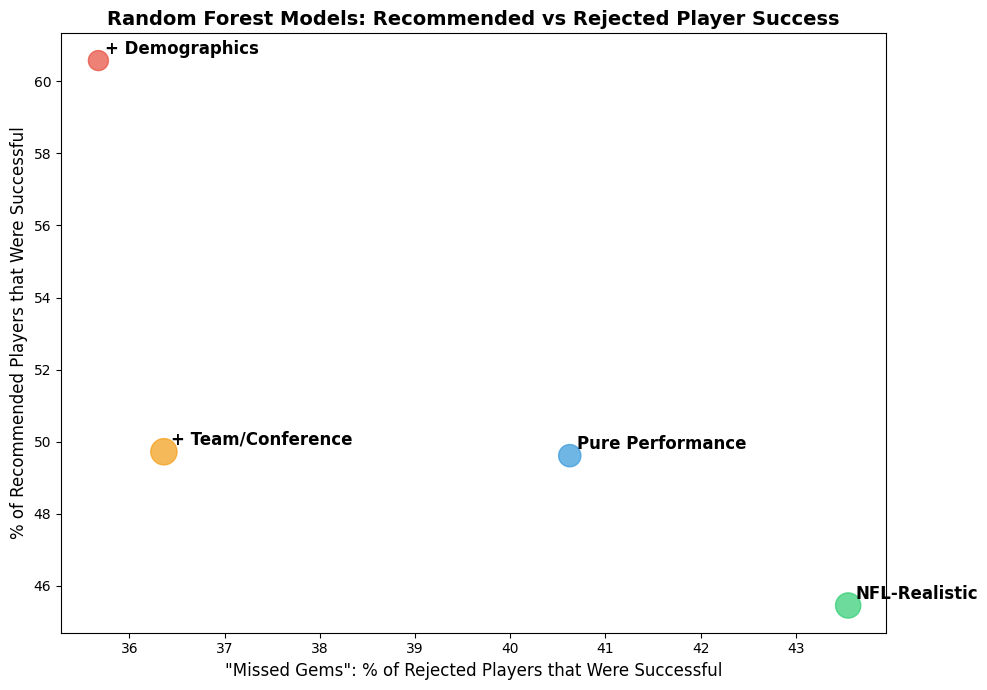

In [ ]:
rf_models = ['A_rf', 'B_rf', 'C_rf', 'D_rf']
rf_summary = []

model_descriptions = {
    'A_rf': 'Pure Performance',
    'B_rf': 'NFL-Realistic', 
    'C_rf': '+ Team/Conference',
    'D_rf': '+ Demographics'
}

for model in rf_models:
    if model in model_performance:
        perf = model_performance[model]
        matrix = perf['matrix']
        
        rec_draft_total = matrix.loc['rec_draft'].sum() if 'rec_draft' in matrix.index else 0
        rec_draft_success = (
            matrix.loc['rec_draft'][['Long_Term_Success', 'Short_Term_Success']].sum() 
            if 'rec_draft' in matrix.index else 0
        )
        success_rate = (rec_draft_success / rec_draft_total * 100) if rec_draft_total > 0 else 0
        
        rej_draft_total = matrix.loc['rej_draft'].sum() if 'rej_draft' in matrix.index else 0
        missed_gems = (
            matrix.loc['rej_draft'][['Long_Term_Success', 'Short_Term_Success']].sum() 
            if 'rej_draft' in matrix.index else 0
        )
        missed_rate = (missed_gems / rej_draft_total * 100) if rej_draft_total > 0 else 0
        
        rf_summary.append({
            'Model': model_descriptions[model],
            'Success_Rate': success_rate,
            'Missed_Gems_Rate': missed_rate,
            'Recommendations': rec_draft_total,
            'Missed_Gems': missed_gems
        })

rf_df = pd.DataFrame(rf_summary)

plt.figure(figsize=(10, 7))
colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C']
plt.scatter(rf_df['Missed_Gems_Rate'], rf_df['Success_Rate'], 
           s=rf_df['Recommendations']*2, c=colors, alpha=0.7)

for i, row in rf_df.iterrows():
    plt.annotate(row['Model'], 
                (row['Missed_Gems_Rate'], row['Success_Rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.xlabel('"Missed Gems": % of Rejected Players that Were Successful', fontsize=12)
plt.ylabel('% of Recommended Players that Were Successful', fontsize=12)
plt.title('Random Forest Models: Recommended vs Rejected Player Success', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



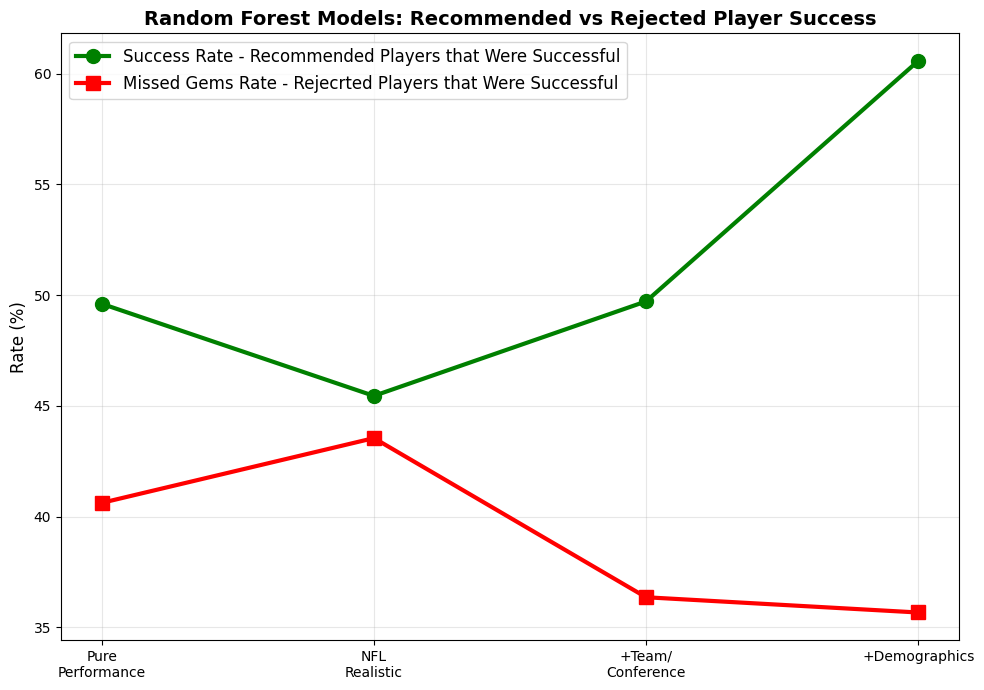

In [ ]:
plt.figure(figsize=(10, 7))
feature_sets = ['Pure\nPerformance', 'NFL\nRealistic', '+Team/\nConference', '+Demographics']
plt.plot(feature_sets, rf_df['Success_Rate'], 'o-', linewidth=3, markersize=10, 
         color='green', label='Success Rate - Recommended Players that Were Successful')
plt.plot(feature_sets, rf_df['Missed_Gems_Rate'], 's-', linewidth=3, markersize=10, 
         color='red', label='Missed Gems Rate - Rejecrted Players that Were Successful')

plt.ylabel('Rate (%)', fontsize=12)
plt.title('Random Forest Models: Recommended vs Rejected Player Success', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()